[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NVlabs/ODISE/blob/master/demo/demo.ipynb)

# Setup and Install

In [1]:
import os
from contextlib import ExitStack
import torch
from PIL import Image
import numpy as np
import tqdm
import matplotlib.pyplot as plt

from detectron2.config import instantiate
from detectron2.data import MetadataCatalog
from detectron2.data import transforms as T
from detectron2.evaluation import inference_context
from detectron2.utils.env import seed_all_rng
from detectron2.utils.logger import setup_logger
from detectron2.utils.visualizer import ColorMode, Visualizer, random_color

from odise import model_zoo
from odise.checkpoint import ODISECheckpointer
from odise.config import instantiate_odise
from odise.modeling.wrapper import OpenPanopticInference

setup_logger()
logger = setup_logger(name="odise");

/home/mfreiberg/miniforge3/envs/odise/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
LARS_STUFF_CLASSES = [
    ["Static Obstacle"],
    ["Water"],
    ["Sky"],
]

LARS_STUFF_CLASSES_EXTENDED = [
    ["Static Obstacle", "Fixed Object", "Immovable Object", "Barrier", "Structure", "Terrain", "Ground", "Land", "Forest", "Trees", "Vegetation", "Plants", "Grass", "Bush", "Foliage", "Beach", "Shore", "Coast", "Sand", "Rocks", "Cliff", "Stone", "Boulder", "Background", "Environment", "Surroundings", "Landscape", "Dock", "Pier", "Jetty", "Building", "Construction"],
    ["Water", "Sea", "Ocean", "Lake", "River", "Pond", "Fluid", "Aquatic surface", "Waterway", "Stream", "Waves", "Liquid"],
    ["Sky", "Clouds", "Atmosphere", "Heavens", "Air", "Horizon", "Celestial", "Firmament"],
]

LARS_STUFF_COLORS = [
    [247, 195, 37],
    [41, 167, 224],
    [90, 75, 164],
]

LARS_THING_CLASSES = [
    ["Boat/ship"],
    ["Row boats"],
    ["Paddle board"],
    ["Buoy"],
    ["Swimmer"],
    ["Animal"],
    ["Float"],
    ["Other"],
]

LARS_THING_COLORS = [
    [255, 87, 51],    # Boat/ship - bright orange-red
    [50, 205, 50],    # Row boats - lime green  
    [255, 0, 255],    # Paddle board - magenta
    [255, 215, 0],    # Buoy - gold
    [0, 128, 128],    # Swimmer - teal
    [139, 69, 19],    # Animal - saddle brown
    [220, 20, 60],    # Float - crimson
    [169, 169, 169],  # Other - dark gray
]

ODISE_TO_LARS_MAPPING = {
    0: 11,
    1: 12,
    2: 13,
    3: 14,
    4: 15,
    5: 16,
    6: 17,
    7: 19,
    8: 1,
    9: 3,
    10: 5,
}

def build_demo_classes_and_metadata(vocab, label_list):
    extra_classes = []

    if vocab:
        for words in vocab.split(";"):
            extra_classes.append([word.strip() for word in words.split(",")])
    extra_colors = [random_color(rgb=True, maximum=1) for _ in range(len(extra_classes))]

    demo_thing_classes = extra_classes
    demo_stuff_classes = []
    demo_thing_colors = extra_colors
    demo_stuff_colors = []

    if "LARS" in label_list:
        demo_thing_classes += LARS_THING_CLASSES
        demo_stuff_classes += LARS_STUFF_CLASSES
        demo_thing_colors += LARS_THING_COLORS
        demo_stuff_colors += LARS_STUFF_COLORS
    if "LARS_EXTENDED" in label_list:
        demo_thing_classes += LARS_THING_CLASSES
        demo_stuff_classes += LARS_STUFF_CLASSES_EXTENDED
        demo_thing_colors += LARS_THING_COLORS
        demo_stuff_colors += LARS_STUFF_COLORS

    MetadataCatalog.pop("odise_demo_metadata", None)
    demo_metadata = MetadataCatalog.get("odise_demo_metadata")
    demo_metadata.thing_classes = [c[0] for c in demo_thing_classes]
    demo_metadata.stuff_classes = [
        *demo_metadata.thing_classes,
        *[c[0] for c in demo_stuff_classes],
    ]
    demo_metadata.thing_colors = demo_thing_colors
    demo_metadata.stuff_colors = demo_thing_colors + demo_stuff_colors
    demo_metadata.stuff_dataset_id_to_contiguous_id = {
        idx: idx for idx in range(len(demo_metadata.stuff_classes))
    }
    demo_metadata.thing_dataset_id_to_contiguous_id = {
        idx: idx for idx in range(len(demo_metadata.thing_classes))
    }

    demo_classes = demo_thing_classes + demo_stuff_classes

    return demo_classes, demo_metadata

In [3]:
class VisualizationDemo(object):
    def __init__(self, model, metadata, aug, instance_mode=ColorMode.IMAGE):
        """
        Args:
            model (nn.Module):
            metadata (MetadataCatalog): image metadata.
            instance_mode (ColorMode):
            parallel (bool): whether to run the model in different processes from visualization.
                Useful since the visualization logic can be slow.
        """
        self.model = model
        self.metadata = metadata
        self.aug = aug
        self.cpu_device = torch.device("cpu")
        self.instance_mode = instance_mode

    def predict(self, original_image):
        """
        Args:
            original_image (np.ndarray): an image of shape (H, W, C) (in BGR order).

        Returns:
            predictions (dict):
                the output of the model for one image only.
                See :doc:`/tutorials/models` for details about the format.
        """
        height, width = original_image.shape[:2]
        aug_input = T.AugInput(original_image, sem_seg=None)
        self.aug(aug_input)
        image = aug_input.image
        image = torch.as_tensor(image.astype("float32").transpose(2, 0, 1))

        inputs = {"image": image, "height": height, "width": width}
        predictions = self.model([inputs])[0]
        return predictions

    def run_on_image(self, image, predictions):
        """
        Args:
            image (np.ndarray): an image of shape (H, W, C) (in BGR order).
                This is the format used by OpenCV.
        Returns:
            predictions (dict): the output of the model.
            vis_output (VisImage): the visualized image output.
        """
        vis_output = None
        # predictions = self.predict(image)
        visualizer = Visualizer(image, self.metadata, instance_mode=self.instance_mode)

        panoptic_seg, segments_info = predictions["panoptic_seg"]
        vis_output = visualizer.draw_panoptic_seg(
            panoptic_seg.to(self.cpu_device), segments_info
        )

        return vis_output
    
    def run_on_image_lars(self, image, predictions):
        # predictions = self.predict(image)

        panoptic_seg, segments_info = predictions["panoptic_seg"]
        
        if isinstance(panoptic_seg, torch.Tensor):
            panoptic_seg = panoptic_seg.cpu().numpy()
        
        panoptic_mask = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        
        for segment in segments_info:
            segment_id = segment["id"]
            is_thing = segment["isthing"]
            category_id = ODISE_TO_LARS_MAPPING[segment["category_id"]]
            
            binary_mask = (panoptic_seg == segment_id)
            
            instance_id = segment_id if is_thing else 0
        
            g_channel = instance_id // 256
            b_channel = instance_id % 256
        
            panoptic_mask[binary_mask, 0] = category_id
            panoptic_mask[binary_mask, 1] = g_channel
            panoptic_mask[binary_mask, 2] = b_channel

        return panoptic_mask


# Load Model

In [4]:

cfg = model_zoo.get_config("Panoptic/odise_label_coco_50e.py", trained=True)

cfg.model.overlap_threshold = 0
seed_all_rng(42)

dataset_cfg = cfg.dataloader.test
wrapper_cfg = cfg.dataloader.wrapper

aug = instantiate(dataset_cfg.mapper).augmentations

model = instantiate_odise(cfg.model)
model.to(cfg.train.device)
ODISECheckpointer(model).load("/data/mfreiberg/weights/ODISE/odise_label_coco_50e-b67d2efc.pth")
"finished loading model"

[03/27 09:10:22 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(1024, 1024), max_size=2560, sample_style='choice')]
LatentDiffusion: Running in eps-prediction mode
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is 768 an

/home/mfreiberg/miniforge3/envs/odise/lib/python3.9/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
The checkpoint state_dict contains keys that are not used by the model:
  model_ema.{decay, num_updates}


[03/27 09:10:44 odise.modeling.backbone.feature_extractor]: backbone_in_size: (512, 512), slide_training: True, 
slide_inference: True, 
min_stride: 4, max_stride: 32, 
projection_dim: 512, 
out_feature_channels: {'s2': 512, 's3': 512, 's4': 512, 's5': 512}
out_feature_strides: {'s2': 4, 's3': 8, 's4': 16, 's5': 32}
use_checkpoint: True

[03/27 09:10:56 odise.modeling.meta_arch.clip]: Using provided CLIP model
[03/27 09:11:03 odise.modeling.meta_arch.clip]: Built text_embed of shape torch.Size([254, 768]) for 133 labels: (('person', 'child', 'girl', 'boy', 'woman', 'man', 'people', 'childeren', 'girls', 'boys', 'women', 'men', 'lady', 'guy', 'ladies', 'guys', 'clothes'), ('bicycle', 'bicycles', 'bike', 'bikes'), ('car', 'cars'), ('motorcycle', 'motorcycles'), ('airplane', 'airplanes'), ('bus', 'buses'), ('train', 'trains', 'locomotive', 'locomotives', 'freight train'), ('truck', 'trucks'), ('boat', 'boats'), ('traffic light',), ('fire hydrant',), ('stop sign',), ('parking meter',), ('b

backbone.feature_extractor.,category_head.clip.clip.,clip_head.clip.clip.


'finished loading model'

Define model predict function

In [8]:
def inference(image, vocab, label_list, lars_format=False):

    image = np.array(image)

    demo_classes, demo_metadata = build_demo_classes_and_metadata(vocab, label_list)
    with ExitStack() as stack:
        inference_model = OpenPanopticInference(
            model=model,
            labels=demo_classes,
            metadata=demo_metadata,
            semantic_on=False,
            instance_on=False,
            panoptic_on=True,
        )
        stack.enter_context(inference_context(inference_model))
        stack.enter_context(torch.no_grad())

        demo = VisualizationDemo(inference_model, demo_metadata, aug)
        
        predictions = demo.predict(image)

        if not lars_format:
            out = demo.run_on_image(image, predictions).get_image()
            return Image.fromarray(out)
        else:
            out = demo.run_on_image(image, predictions).get_image()
            out_lars = demo.run_on_image_lars(image, predictions)
            return (Image.fromarray(out), Image.fromarray(out_lars))


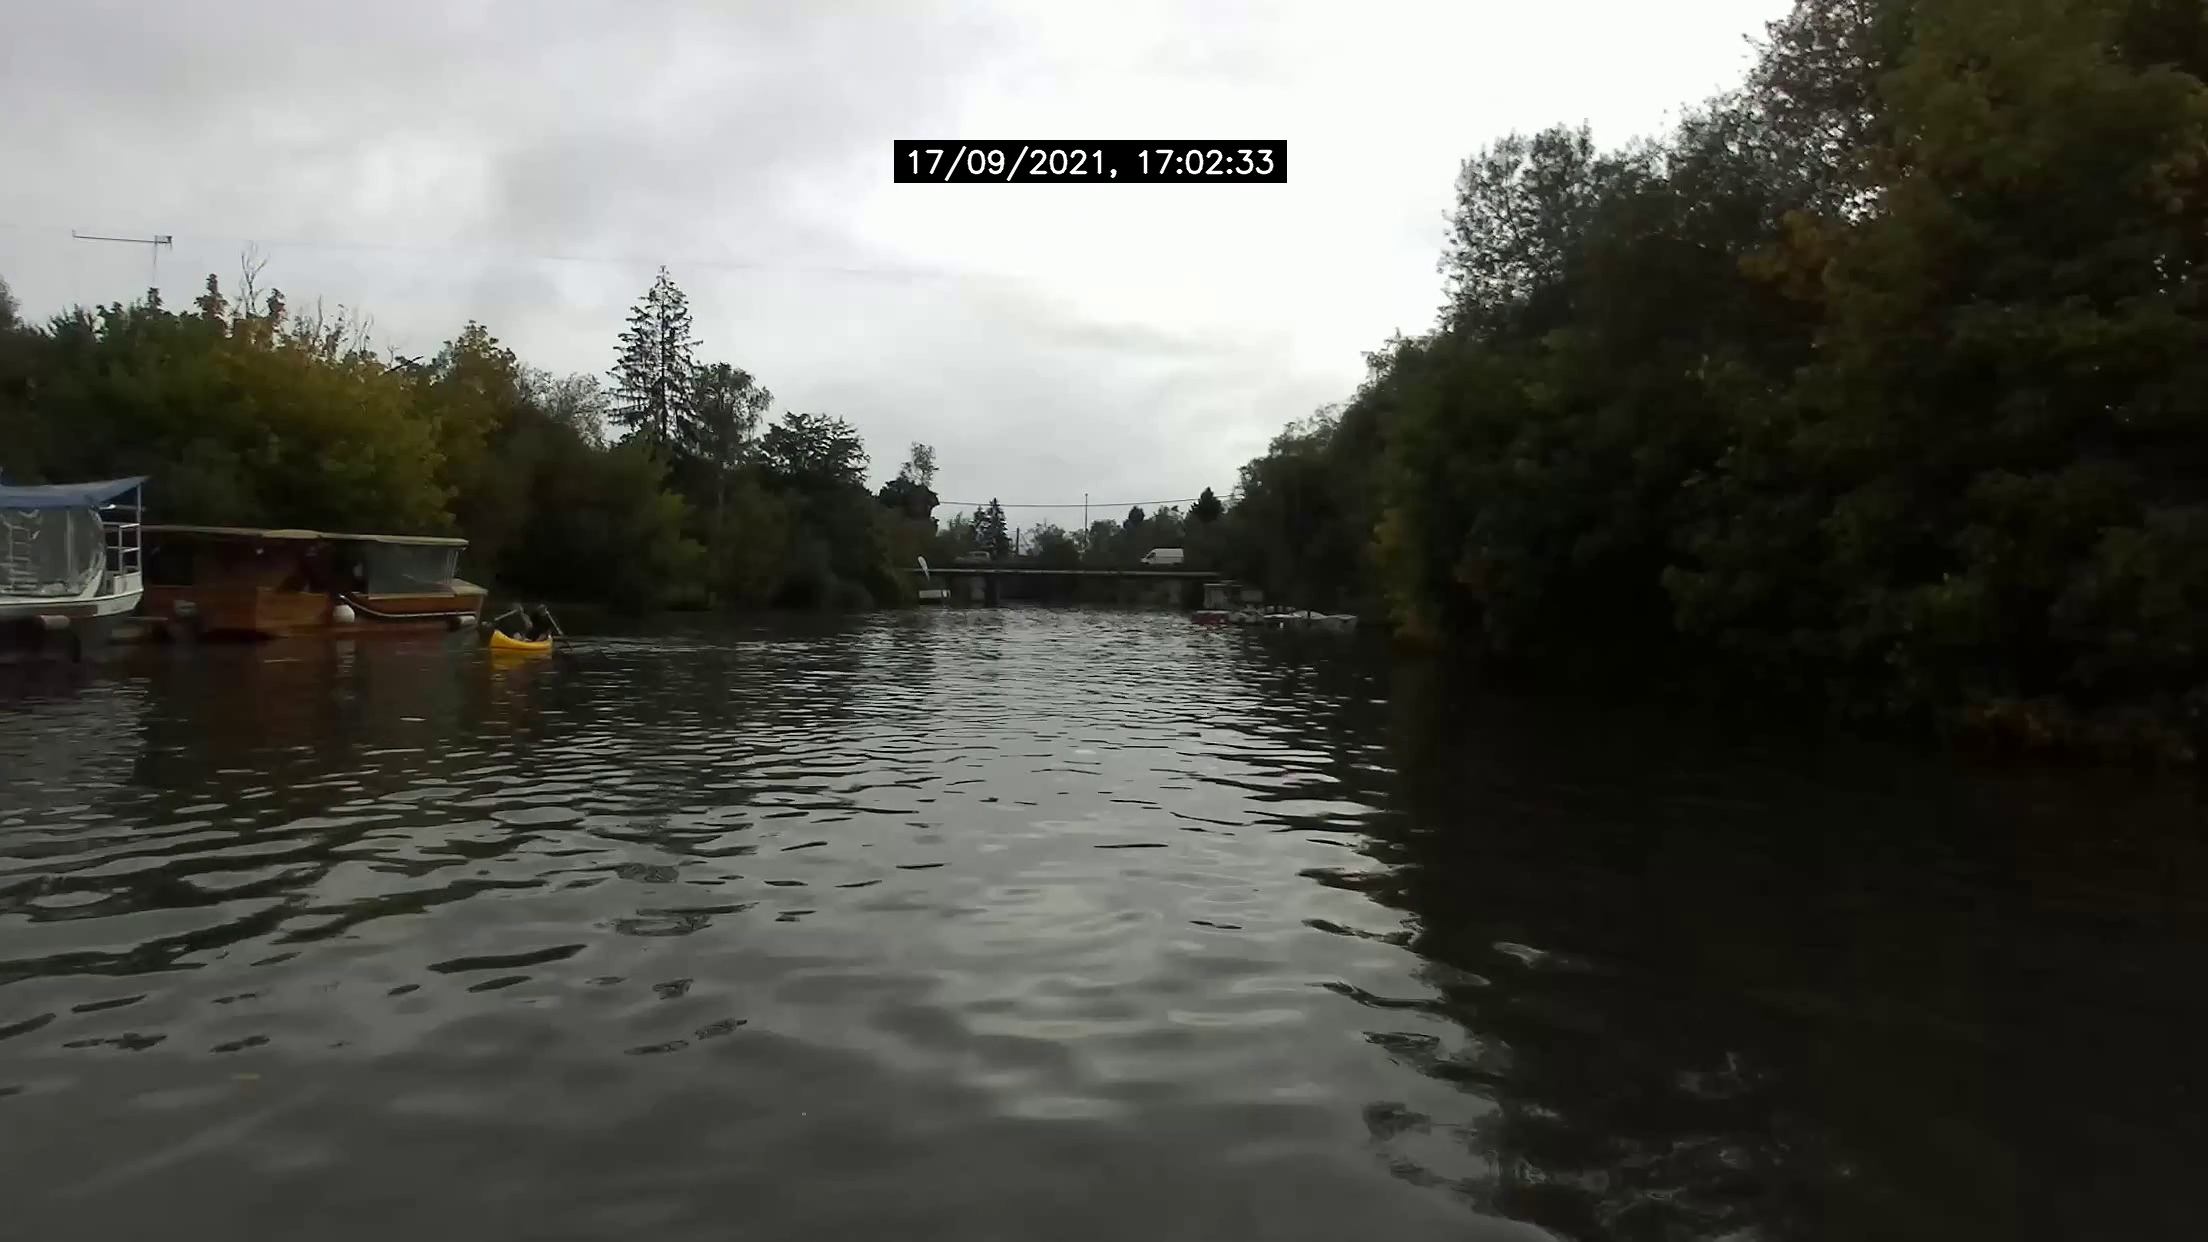

In [6]:
input_image = Image.open("/data/mfreiberg/datasets/lars/val/images/davimar_seq_08_00008.jpg")
input_image

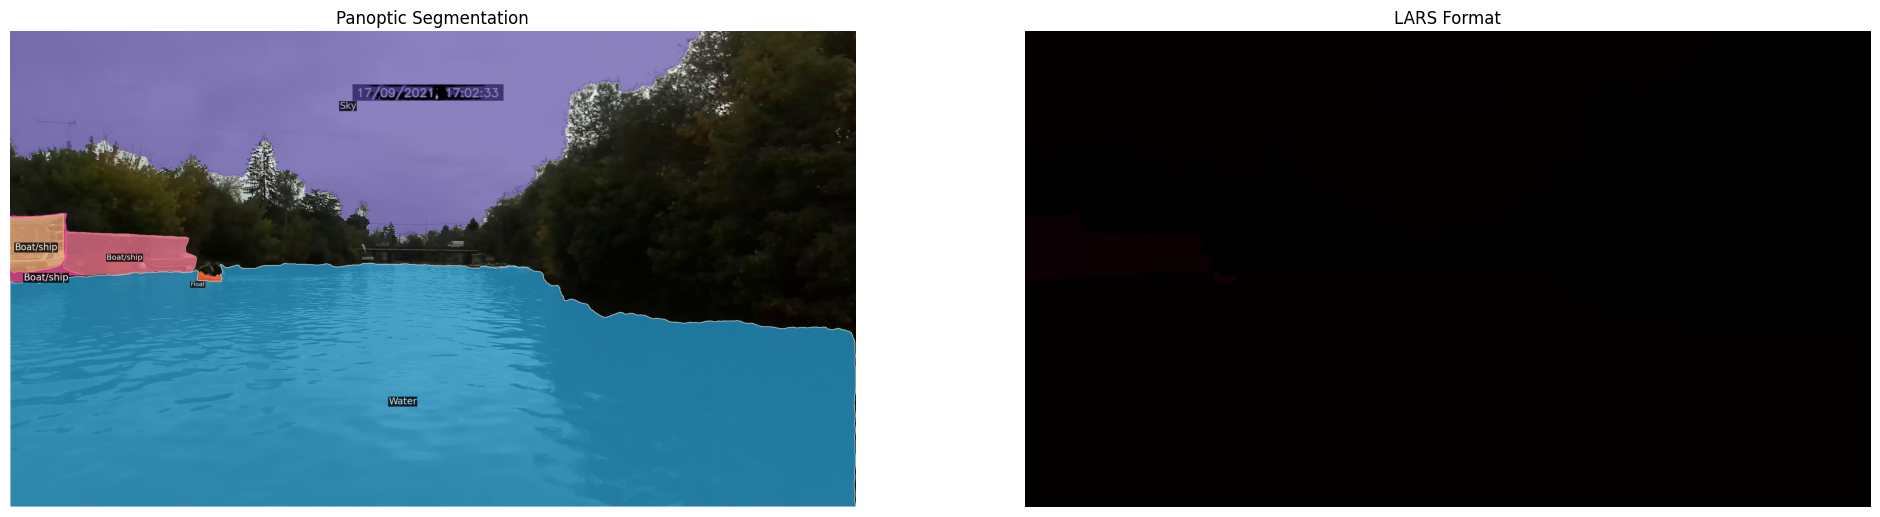

In [10]:
vocab = ""
label_list = ["LARS"]

img, img_lars = inference(input_image, vocab, label_list, lars_format=True)

# Display the images side by side using matplotlib
fig, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].imshow(img)
axes[0].set_title('Panoptic Segmentation')
axes[0].axis('off')

axes[1].imshow(img_lars)
axes[1].set_title('LARS Format')
axes[1].axis('off')

plt.show()

[03/27 09:17:44 odise.modeling.meta_arch.clip]: Using provided CLIP model
[03/27 09:17:44 odise.modeling.meta_arch.clip]: Built text_embed of shape torch.Size([60, 768]) for 11 labels: (('Boat/ship',), ('Row boats',), ('Paddle board',), ('Buoy',), ('Swimmer',), ('Animal',), ('Float',), ('Other',), ('Static Obstacle', 'Fixed Object', 'Immovable Object', 'Barrier', 'Structure', 'Terrain', 'Ground', 'Land', 'Forest', 'Trees', 'Vegetation', 'Plants', 'Grass', 'Bush', 'Foliage', 'Beach', 'Shore', 'Coast', 'Sand', 'Rocks', 'Cliff', 'Stone', 'Boulder', 'Background', 'Environment', 'Surroundings', 'Landscape', 'Dock', 'Pier', 'Jetty', 'Building', 'Construction'), ('Water', 'Sea', 'Ocean', 'Lake', 'River', 'Pond', 'Fluid', 'Aquatic surface', 'Waterway', 'Stream', 'Waves', 'Liquid'), ('Sky', 'Clouds', 'Atmosphere', 'Heavens', 'Air', 'Horizon', 'Celestial', 'Firmament'))
[03/27 09:17:44 odise.modeling.meta_arch.clip]: Using provided CLIP model
[03/27 09:17:44 odise.modeling.meta_arch.clip]: Built

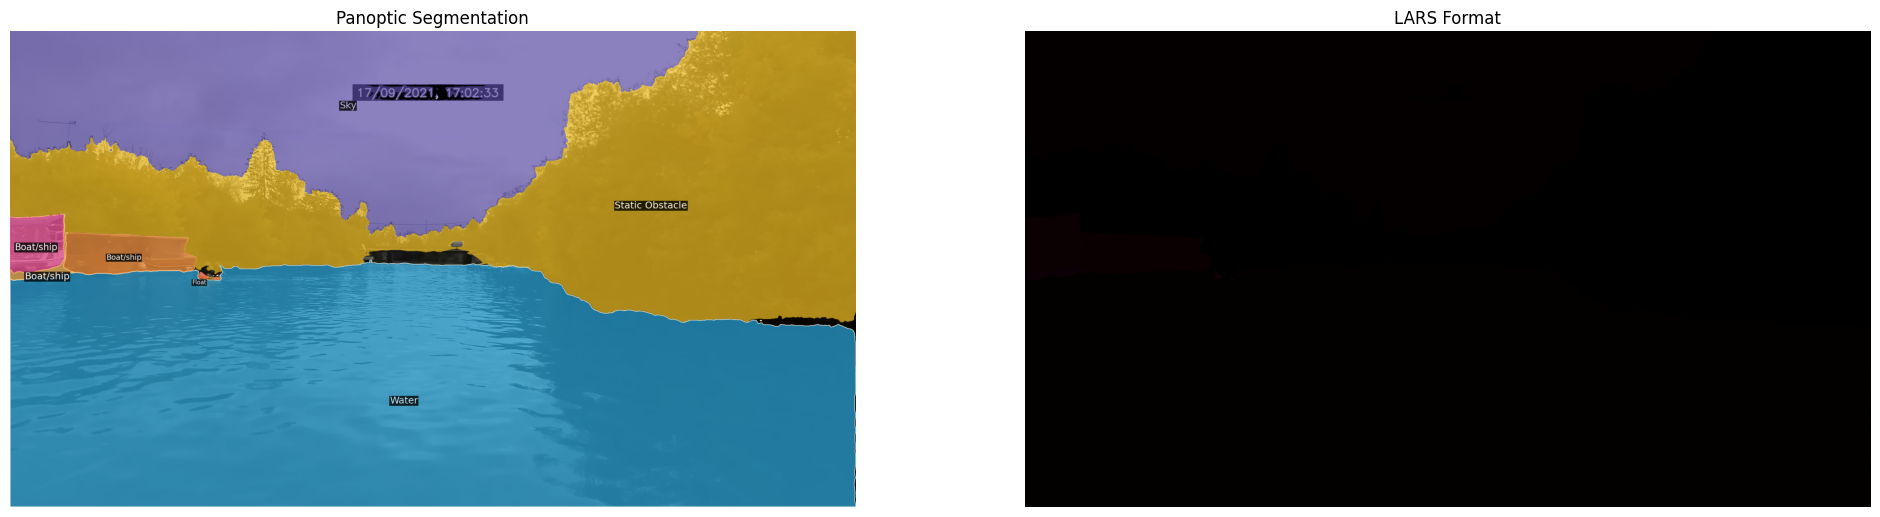

In [12]:
vocab = ""
label_list = ["LARS_EXTENDED"]

img, img_lars = inference(input_image, vocab, label_list, lars_format=True)

# Display the images side by side using matplotlib
fig, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].imshow(img)
axes[0].set_title('Panoptic Segmentation')
axes[0].axis('off')

axes[1].imshow(img_lars)
axes[1].set_title('LARS Format')
axes[1].axis('off')

plt.show()

In [15]:
vocab = ""
label_list = ["LARS"]

out_dir = os.path.join("/data/mfreiberg/predictions", f"odise_lars_val")
out_dir_panop = os.path.join(out_dir, "panop")
out_dir_lars_format = os.path.join(out_dir, "lars_format")

os.makedirs(out_dir, exist_ok=True)
os.makedirs(out_dir_panop, exist_ok=True)
os.makedirs(out_dir_lars_format, exist_ok=True)

lars_val_dir = "/data/mfreiberg/datasets/lars/val"
image_list_path = os.path.join(lars_val_dir, "image_list.txt")

with open(image_list_path, "r") as f:
    image_names = [line.strip() for line in f.readlines()]


for image_name in tqdm.tqdm(image_names, desc="Processing images"):
    img_path = os.path.join(lars_val_dir, "images", f"{image_name}.jpg")
    image = Image.open(img_path)

    (out_img, out_img_lars_format) = inference(image, vocab, label_list, lars_format=True)
    out_img.save(os.path.join(out_dir_panop, f"{image_name}.png"))
    out_img_lars_format.save(os.path.join(out_dir_lars_format, f"{image_name}.png"))


Processing images: 100%|██████████| 198/198 [12:15<00:00,  3.72s/it]


In [17]:
vocab = ""
label_list = ["LARS_EXTENDED"]

out_dir = os.path.join("/data/mfreiberg/predictions", f"odise_lars_val_extended")
out_dir_panop = os.path.join(out_dir, "panop")
out_dir_lars_format = os.path.join(out_dir, "lars_format")

os.makedirs(out_dir, exist_ok=True)
os.makedirs(out_dir_panop, exist_ok=True)
os.makedirs(out_dir_lars_format, exist_ok=True)

lars_val_dir = "/data/mfreiberg/datasets/lars/val"
image_list_path = os.path.join(lars_val_dir, "image_list.txt")

with open(image_list_path, "r") as f:
    image_names = [line.strip() for line in f.readlines()]


for image_name in tqdm.tqdm(image_names, desc="Processing images"):
    img_path = os.path.join(lars_val_dir, "images", f"{image_name}.jpg")
    image = Image.open(img_path)

    (out_img, out_img_lars_format) = inference(image, vocab, label_list, lars_format=True)
    out_img.save(os.path.join(out_dir_panop, f"{image_name}.png"))
    out_img_lars_format.save(os.path.join(out_dir_lars_format, f"{image_name}.png"))


Processing images: 100%|██████████| 198/198 [12:53<00:00,  3.91s/it]
